# Circle Benchmark: Tangent-Linearized Gaussian Inference

It reproduces the **isotropic circle benchmark** (Section III of the paper) and
extends it with anisotropic covariance stress tests and mean-offset sweeps.

**Setting.**  Manifold $\mathcal{M} = \{x \in \mathbb{R}^2 : \|x\| = R\}$,
curvature $\kappa = 1/R$, reach $\rho = R$.  Ambient
$X \sim \mathcal{N}(\mu, \Sigma)$ with $\mu = (R + \delta, 0)$, linearization
point $\tilde\mu = g(\mu) = (R, 0)$.

In [ ]:
#!/usr/bin/env python3
"""
Overconfidence diagnostics for tangent-linearized Gaussian inference
on the circle manifold.
===================================================================

Setting
-------
Manifold  : circle  M = {x in R^2 : ||x|| = R}, curvature kappa = 1/R, reach rho = R
Ambient   : X ~ N(mu, Sigma), with mu = (R + delta, 0)
Lin. point: mu_tilde = g(mu) = (R, 0)

This script reproduces the isotropic circle benchmark and extends it with:
  1) anisotropic covariance stress tests (different normal/tangential spreads),
  2) mean-offset delta sweeps to expose tail/leakage growth in Theorem III.1.
"""

import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import TwoSlopeNorm
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from scipy.integrate import cumulative_trapezoid
from scipy.stats import norm as sp_norm, ncx2

# ═══════════════════════════════════════════════════════════════
#  Global settings
# ═══════════════════════════════════════════════════════════════
DELTA = 0.2  # offset: μ = (R + δ, 0)
SEED = 42
FIGDIR = "notebook_figures"
FIG_DPI = 600
os.makedirs(FIGDIR, exist_ok=True)


def setup_publication_style():
    """Match plotting style used in planar_pushing.py."""
    plt.rcParams.update(
        {
            "font.family": "serif",
            "font.serif": ["Times New Roman", "DejaVu Serif"],
            "font.size": 10,
            "axes.labelsize": 11,
            "axes.titlesize": 11,
            "xtick.labelsize": 9,
            "ytick.labelsize": 9,
            "legend.fontsize": 9,
            "figure.dpi": 150,
            "savefig.dpi": FIG_DPI,
            "savefig.format": "png",
            "savefig.bbox": "tight",
            "savefig.pad_inches": 0.05,
            "axes.linewidth": 0.8,
            "lines.linewidth": 1.5,
            "axes.facecolor": "white",
            "figure.facecolor": "white",
            "legend.frameon": True,
            "legend.framealpha": 0.92,
            "legend.edgecolor": "#c8c8c8",
            "text.usetex": False,
            "pdf.fonttype": 42,
            "ps.fonttype": 42,
        }
    )


setup_publication_style()

RNG = np.random.default_rng(SEED)
_COND_CDF_CACHE = {}


def _polish_axis(ax):
    """Apply light major/minor gridlines for publication readability."""
    ax.grid(True, which="major", color="#d0d0d0", linewidth=0.6, alpha=0.6)
    ax.grid(True, which="minor", color="#ececec", linewidth=0.5, alpha=0.5)


def _save_high_dpi_png(fig, stem):
    """Save figure as high-DPI PNG."""
    outpath = os.path.join(FIGDIR, f"{stem}.png")
    fig.savefig(outpath, format="png", dpi=FIG_DPI)
    plt.close(fig)
    print(f"  → {outpath}")

## 1. Core Geometric Functions

- **Exact marginalization** (metric projection): $Y = R \cdot X / \|X\|$
- **Tangent-retraction approximation** (linearized marginalization): project
  $X - \tilde\mu$ onto $T_{\tilde\mu}\mathcal{M}$ then normalize back to the
  circle.
- **Exact conditioning** (surface-measure): sample via inverse CDF of the
  conditioned angular density
  $p(\theta) \propto \exp\!\bigl(-\tfrac12 (x(\theta)-\mu)^\top
  \Sigma^{-1} (x(\theta)-\mu)\bigr)$.
- **Linearized conditioning**: Gaussian condition on the tangent line, then
  retract.


In [2]:
def make_covariance_tangent_normal(sigma_t, anisotropy=1.0):
    """
    Build Sigma in the (normal, tangent) frame at mu_tilde=(R,0):
      sigma_n = anisotropy * sigma_t.
    For the chosen benchmark orientation this frame aligns with (x,y), so
      Sigma = diag(sigma_n^2, sigma_t^2).
    """
    sigma_n = float(anisotropy) * float(sigma_t)
    return np.diag([sigma_n**2, float(sigma_t) ** 2])


def spectral_std(cov):
    """sqrt(||Sigma||_op)."""
    return float(np.sqrt(np.max(np.linalg.eigvalsh(cov))))


def locality_radius(R, cov, r_factor=3.0):
    """Use r = min(r_factor*sqrt(||Sigma||_op), R/2)."""
    return min(float(r_factor) * spectral_std(cov), R / 2.0 - 1e-12)


# ═══════════════════════════════════════════════════════════════
#  1. Core geometric functions
# ═══════════════════════════════════════════════════════════════


def sample_ambient(mu, cov, N, rng=RNG):
    """X ~ N(mu, Sigma), returns array of shape (N, 2)."""
    return rng.multivariate_normal(mean=mu, cov=cov, size=N)


def exact_marg(X, R):
    """Exact marginalization (metric projection):  Y = R X / ‖X‖."""
    norms = np.linalg.norm(X, axis=1, keepdims=True)
    norms = np.maximum(norms, 1e-15)
    return R * X / norms


def lin_marg(X, R, tmu):
    """
    Tangent–retraction approximation for marginalization.
    1. Project (X − μ̃) onto T_{μ̃}M (tangent line).
    2. Retract by normalising back to the circle.
    """
    tan = np.array([-tmu[1], tmu[0]]) / R  # unit tangent
    t = (X - tmu) @ tan  # tangential coords (N,)
    pts = tmu[np.newaxis, :] + t[:, np.newaxis] * tan[np.newaxis, :]
    norms = np.linalg.norm(pts, axis=1, keepdims=True)
    norms = np.maximum(norms, 1e-15)
    return R * pts / norms


def _get_cond_cdf(R, mu, cov, n_grid):
    """
    Cache CDF of exact conditioned angular density:
      p(theta) propto exp(-0.5 * (x(theta)-mu)^T Sigma^{-1} (x(theta)-mu)).
    """
    key = (
        round(float(R), 10),
        tuple(np.round(mu.astype(float), 10)),
        tuple(np.round(cov.astype(float).ravel(), 10)),
        int(n_grid),
    )
    cached = _COND_CDF_CACHE.get(key)
    if cached is not None:
        return cached

    theta = np.linspace(-np.pi, np.pi, int(n_grid), endpoint=False)
    pts = np.column_stack([R * np.cos(theta), R * np.sin(theta)])
    diff = pts - mu[np.newaxis, :]
    omega = np.linalg.inv(cov)
    quad = np.einsum("ni,ij,nj->n", diff, omega, diff)
    logp = -0.5 * quad
    logp -= float(np.max(logp))
    p = np.exp(logp)
    p /= float(np.sum(p))
    cdf = np.cumsum(p)
    cdf /= float(cdf[-1])
    _COND_CDF_CACHE[key] = (theta, cdf)
    return theta, cdf


def exact_cond_samples(R, mu, cov, N, rng=RNG, n_grid=16_000):
    """
    Sample exact surface-measure conditioned law via inverse CDF.
    """
    theta, cdf = _get_cond_cdf(R, mu, cov, n_grid=n_grid)
    u = rng.random(N)
    idx = np.searchsorted(cdf, u).clip(0, len(theta) - 1)
    th = theta[idx]
    return np.column_stack([R * np.cos(th), R * np.sin(th)])


def lin_cond_samples(R, mu, cov, N, tmu, rng=RNG):
    """
    Linearized conditioning: condition on tangent line, then retract.
    For tangent basis tan, with Omega = Sigma^{-1} and delta = mu - mu_tilde:
        sigma_T = (tan^T Omega tan)^(-1),
        m_T     = sigma_T * tan^T Omega delta,
        v ~ N(m_T, sigma_T).
    """
    tan = np.array([-tmu[1], tmu[0]]) / R
    delta = mu - tmu
    omega = np.linalg.inv(cov)
    sigma_T = 1.0 / float(tan @ omega @ tan)
    m_T = sigma_T * float(tan @ omega @ delta)
    v = m_T + np.sqrt(sigma_T) * rng.standard_normal(N)
    pts = tmu[np.newaxis, :] + v[:, np.newaxis] * tan[np.newaxis, :]
    norms = np.linalg.norm(pts, axis=1, keepdims=True)
    norms = np.maximum(norms, 1e-15)
    return R * pts / norms

## 2. Analysis Helpers

Angular statistics and calibration diagnostics used by every figure below.


In [3]:

# ═══════════════════════════════════════════════════════════════
#  2. Analysis helpers
# ═══════════════════════════════════════════════════════════════


def _ang(Y):
    """Angles in (−π, π]."""
    return np.arctan2(Y[:, 1], Y[:, 0])


def angular_stats(Y):
    """Circular mean and (linearised) standard deviation."""
    th = _ang(Y)
    S, C = np.mean(np.sin(th)), np.mean(np.cos(th))
    mu = np.arctan2(S, C)
    c = (th - mu + np.pi) % (2 * np.pi) - np.pi
    return float(mu), float(np.std(c))


def overconf_ratio(Y_ex, Y_li):
    """
    Variance ratio   Var_lin / Var_exact.
        < 1  ⇒  linearised is *overconfident* (underestimates spread).
        > 1  ⇒  linearised is conservative.
    """
    _, s_ex = angular_stats(Y_ex)
    _, s_li = angular_stats(Y_li)
    return (s_li / max(s_ex, 1e-15)) ** 2


def coverage(Y_ex, Y_li, level=0.95):
    """
    Construct a level-% angular CI from the linearised distribution
    and measure what fraction of *exact* samples falls inside.
    If overconfident (CI too narrow), coverage < nominal level.
    """
    mu_li, std_li = angular_stats(Y_li)
    z = sp_norm.ppf(0.5 + level / 2.0)
    hw = z * std_li
    th = _ang(Y_ex)
    c = (th - mu_li + np.pi) % (2 * np.pi) - np.pi
    return float(np.mean(np.abs(c) <= hw))


def cov_frob_error(Y_ex, Y_li):
    """‖Cov(Y_exact) − Cov(Y_lin)‖_F  in ℝ²."""
    return float(np.linalg.norm(np.cov(Y_ex.T) - np.cov(Y_li.T), "fro"))


def w2_coupling_proxy(Y_ex, Y_li):
    """
    Coupling-based empirical W2 proxy:
      sqrt(E ||Y_exact - Y_lin||^2) under the paired-sample coupling.
    This upper-bounds the true W2 and tracks theorem-controlled trend directly.
    """
    d = Y_ex - Y_li
    return float(np.sqrt(np.mean(np.sum(d * d, axis=1))))

## 3. $W_2$ Bound Quantities (Theorem III.1 specialized to the circle)

Closed-form local + tail decomposition of the Wasserstein-2 bound used in
panel (c) of Fig. 2, together with the data-driven calibrators for $C_{\mathrm{loc}}$
and the $C_{\mathrm{tail}}$ scale.


In [4]:

# ═══════════════════════════════════════════════════════════════
#  3. W₂ bound quantities  (Theorem 1 specialised to circle)
# ═══════════════════════════════════════════════════════════════


def fourth_moment_gaussian(cov, delta_vec):
    """
    E[||X - mu_tilde||^4] for X ~ N(mu, Sigma), delta = mu - mu_tilde.
    Closed form used in Sec. III:
      ||delta||^4
      + 2 ||delta||^2 tr(Sigma)
      + 4 delta^T Sigma delta
      + (tr(Sigma))^2
      + 2 ||Sigma||_F^2.
    """
    delta_sq = float(delta_vec @ delta_vec)
    tr_cov = float(np.trace(cov))
    fro_sq = float(np.linalg.norm(cov, "fro") ** 2)
    quad = float(delta_vec @ cov @ delta_vec)
    return delta_sq**2 + 2.0 * delta_sq * tr_cov + 4.0 * quad + tr_cov**2 + 2.0 * fro_sq


def _is_isotropic_cov(cov, rel_tol=1e-8, abs_tol=1e-12):
    """Check whether covariance is (numerically) isotropic."""
    if cov.shape[0] != cov.shape[1]:
        return False
    n = cov.shape[0]
    sigma2 = float(np.trace(cov)) / float(n)
    return np.allclose(cov, sigma2 * np.eye(n), rtol=rel_tol, atol=abs_tol)


def tail_prob_gaussian(r, cov, delta_vec, n=2):
    """
    Tail leakage epsilon = P(||X - mu_tilde|| > r).
    Uses exact non-central chi-square survival for isotropic Gaussian;
    otherwise falls back to a concentration upper bound.
    """
    if _is_isotropic_cov(cov):
        sigma = np.sqrt(max(float(np.trace(cov)) / cov.shape[0], 1e-15))
        lam = float(delta_vec @ delta_vec) / max(sigma**2, 1e-15)
        y = (float(r) / sigma) ** 2
        return float(ncx2.sf(y, df=cov.shape[0], nc=lam))

    delta_norm = float(np.linalg.norm(delta_vec))
    if r <= delta_norm:
        return 1.0
    lam_max = float(np.max(np.linalg.eigvalsh(cov)))
    arg = (r - delta_norm) / np.sqrt(lam_max) - np.sqrt(n)
    if arg <= 0:
        return 1.0
    return float(np.exp(-0.5 * arg**2))


def _tail_and_trunc_m4_over_radii(radii, cov, delta_vec, mc_samples=80_000):
    """
    Evaluate epsilon(r) and E[||X-mu_tilde||^4 1_{||X-mu_tilde||<=r}] over radii.
    Isotropic case: non-central chi-square + numerical quadrature.
    General case: sample-based approximation (empirical CDF/moment).
    """
    radii = np.asarray(radii, dtype=float)

    if _is_isotropic_cov(cov):
        sigma = np.sqrt(max(float(np.trace(cov)) / cov.shape[0], 1e-15))
        delta_norm = float(np.linalg.norm(delta_vec))
        lam = (delta_norm / sigma) ** 2
        y = (radii / sigma) ** 2
        y_max = float(np.max(y))
        n_quad = int(np.clip(2048 + 160 * np.sqrt(max(y_max, 1.0)), 2048, 12000))
        y_grid = np.linspace(0.0, y_max, n_quad)
        pdf = ncx2.pdf(y_grid, df=cov.shape[0], nc=lam)
        m2_grid = cumulative_trapezoid((y_grid**2) * pdf, y_grid, initial=0.0)
        m2_vals = np.interp(y, y_grid, m2_grid, left=0.0, right=float(m2_grid[-1]))
        eps_vals = ncx2.sf(y, df=cov.shape[0], nc=lam)
        trunc_m4_vals = (sigma**4) * m2_vals
        return np.clip(eps_vals, 0.0, 1.0), np.maximum(trunc_m4_vals, 0.0)

    # Anisotropic fallback: empirical CDF and truncated moments from samples.
    seed = int(
        SEED
        + 13 * round(1e6 * float(np.trace(cov)))
        + 17 * round(1e5 * float(np.linalg.norm(delta_vec)))
    ) % (2**32 - 1)
    rng_local = np.random.default_rng(seed)
    Z = rng_local.multivariate_normal(mean=delta_vec, cov=cov, size=int(mc_samples))
    rad = np.linalg.norm(Z, axis=1)
    rad4 = rad**4

    order = np.argsort(rad)
    rad_sorted = rad[order]
    rad4_cumsum = np.cumsum(rad4[order])

    counts = np.searchsorted(rad_sorted, radii, side="right")
    trunc_m4_vals = np.zeros_like(radii)
    valid = counts > 0
    trunc_m4_vals[valid] = rad4_cumsum[counts[valid] - 1] / float(mc_samples)
    eps_vals = 1.0 - counts / float(mc_samples)
    return np.clip(eps_vals, 0.0, 1.0), np.maximum(trunc_m4_vals, 0.0)


def calibrate_local_constant_circle(
    R, cov, delta_vec, r, quantile=0.90, n_samples=12_000, default_value=0.5
):
    """
    Data-driven C_loc calibration suggested by the theorem discussion:
      c_hat = ||g(x)-R_mu_tilde(Pi_T(x-mu_tilde))|| / ((kappa+kappa_R)||x-mu_tilde||^2).
    We use a high quantile over local samples (||x-mu_tilde||<=r).
    """
    tmu = np.array([R, 0.0], dtype=float)
    mu = tmu + np.asarray(delta_vec, dtype=float)
    seed = int(
        SEED
        + 101 * round(1e3 * float(R))
        + 103 * round(1e6 * float(np.trace(cov)))
        + 107 * round(1e5 * float(np.linalg.norm(delta_vec)))
    ) % (2**32 - 1)
    rng_local = np.random.default_rng(seed)
    X = sample_ambient(mu, cov, int(n_samples), rng_local)
    dX = X - tmu[np.newaxis, :]
    rad = np.linalg.norm(dX, axis=1)
    mask = rad <= float(r)

    if np.count_nonzero(mask) < max(80, int(0.02 * n_samples)):
        return float(default_value)

    Y_ex = exact_marg(X[mask], R)
    Y_li = lin_marg(X[mask], R, tmu)
    residual = np.linalg.norm(Y_ex - Y_li, axis=1)
    denom = (2.0 / R) * np.maximum(rad[mask] ** 2, 1e-12)
    c_hat = residual / denom
    c_hat = c_hat[np.isfinite(c_hat)]
    if c_hat.size == 0:
        return float(default_value)

    c_loc = float(np.quantile(c_hat, float(quantile)))
    # Keep a small positive floor to avoid numerical collapse while
    # preventing excessive low-noise conservatism.
    return float(np.clip(c_loc, 0.005, 2.0))


def w2_bound_marg(
    R,
    cov,
    delta_vec,
    C_loc=0.5,
    r_factor=3.0,
    optimize_r=True,
    n_r_grid=24,
    calibrate_cloc=True,
    cloc_quantile=0.90,
    C_tail_scale=1.0,
    return_components=False,
):
    """
    W₂ bound (Theorem 1) for the circle:
        C_loc·(κ+κ_R)·√(E[‖X−μ̃‖⁴·1_A])  +  C_tail·ε^{1/4}
    with kappa = kappa_R = 1/R.
    We tighten the practical proxy by:
      (i) calibrating C_loc from local residual samples,
      (ii) using exact isotropic Gaussian tail/truncated moments, and
      (iii) selecting r by minimizing local + tail terms over admissible radii.
    """
    kappa_total = 2.0 / R
    sigma_eff = spectral_std(cov)
    delta_norm = float(np.linalg.norm(delta_vec))
    r_half = R / 2.0 - 1e-12
    fm = fourth_moment_gaussian(cov, delta_vec)
    C_tail_theory = 2.0 * fm**0.25
    C_tail_eff = float(C_tail_scale) * C_tail_theory

    r_nominal = min(locality_radius(R, cov, r_factor=r_factor), r_half)
    C_loc_eff = float(C_loc)
    if calibrate_cloc:
        # Use a coverage-aware calibration radius so C_loc does not fall back
        # to a large default in low-noise settings with nonzero offset delta.
        r_calibration = min(
            r_half,
            max(r_nominal, delta_norm + 2.5 * sigma_eff, 0.20 * R),
        )
        C_loc_eff = calibrate_local_constant_circle(
            R,
            cov,
            delta_vec,
            r_calibration,
            quantile=cloc_quantile,
            default_value=C_loc,
        )

    if optimize_r:
        # Search the full admissible local tube, not only O(sigma), to avoid
        # pathological epsilon≈1 choices in very low-noise regimes.
        r_min = max(0.20 * sigma_eff, 1e-6)
        r_max = r_half
        if r_max <= r_min:
            radii = np.array([max(min(r_nominal, r_half), 1e-6)])
        else:
            radii = np.geomspace(r_min, r_max, int(n_r_grid))
    else:
        radii = np.array([min(max(r_nominal, 1e-6), r_half)], dtype=float)

    eps_vals, trunc_m4_vals = _tail_and_trunc_m4_over_radii(radii, cov, delta_vec)
    local_vals = C_loc_eff * kappa_total * np.sqrt(np.maximum(trunc_m4_vals, 0.0))
    tail_weight_vals = np.clip(eps_vals, 0.0, 1.0) ** 0.25
    total_vals = local_vals + C_tail_eff * tail_weight_vals
    idx_best = int(np.argmin(total_vals))
    bound_best = float(total_vals[idx_best])
    if not return_components:
        return bound_best

    return {
        "bound": bound_best,
        "local": float(local_vals[idx_best]),
        "tail_weight": float(tail_weight_vals[idx_best]),
        "eps": float(np.clip(eps_vals[idx_best], 0.0, 1.0)),
        "r_selected": float(radii[idx_best]),
        "C_loc_effective": float(C_loc_eff),
        "C_tail_theory": float(C_tail_theory),
        "C_tail_effective": float(C_tail_eff),
    }


def calibrate_c_tail_scale_quantile(
    empirical_w2,
    local_terms,
    tail_weights,
    c_tail_theory,
    x_diag,
    vb,
    quantile=0.90,
    enforce_upper_envelope=True,
    envelope_margin=0.02,
):
    """
    Calibrate multiplicative C_tail scale via a quantile upper-envelope fit:
      empirical_w2 <= local + scale * C_tail_theory * eps^{1/4}.
    Uses transition/outside-validity region first (tail-sensitive), then falls back to all points.
    When enforce_upper_envelope=True, additionally guarantees scale is large enough
    so the resulting bound stays above all empirical points.
    """
    empirical_w2 = np.asarray(empirical_w2, dtype=float)
    local_terms = np.asarray(local_terms, dtype=float)
    tail_weights = np.asarray(tail_weights, dtype=float)
    c_tail_theory = np.asarray(c_tail_theory, dtype=float)
    x_diag = np.asarray(x_diag, dtype=float)

    tail_contrib = c_tail_theory * tail_weights
    needed_scale = np.maximum(empirical_w2 - local_terms, 0.0) / np.maximum(
        tail_contrib, 1e-12
    )

    # Focus on tail-active region near/after transition first.
    mask = (
        np.isfinite(needed_scale)
        & (tail_contrib > 1e-10)
        & (x_diag >= 0.70 * float(vb))
    )
    if np.count_nonzero(mask) < 4:
        mask = np.isfinite(needed_scale) & (tail_contrib > 1e-10)
    if np.count_nonzero(mask) == 0:
        return 1.0

    scale_quant = float(np.quantile(needed_scale[mask], float(quantile)))
    if not np.isfinite(scale_quant):
        scale_quant = 1.0

    valid_needed = needed_scale[np.isfinite(needed_scale)]
    scale_env = float(np.max(valid_needed)) if valid_needed.size else scale_quant
    if not np.isfinite(scale_env):
        scale_env = scale_quant

    if enforce_upper_envelope:
        scale = max(scale_quant, (1.0 + float(envelope_margin)) * scale_env)
    else:
        scale = scale_quant

    return float(np.clip(scale, 0.01, 10.0))


def validity_boundary_sigma_over_R():
    """
    Spectral threshold from r = 3*sqrt(||Sigma||_op) and r < R/2:
      sqrt(||Sigma||_op) / R < 1/6.
    In isotropic settings this reduces to sigma/R < 1/6.
    """
    return 1.0 / 6.0

## 4. Figure 1 — Visual Demonstration

Four-column visual, from inside → outside the validity region.  Top row:
circle with confidence arcs and scatter of exact vs linearized samples.
Bottom row: angular density histograms with $\pm 2\sigma_\theta$ shading.


In [5]:

# ═══════════════════════════════════════════════════════════════
#  4. Figure 1 — Visual demonstration
#     Top  : circle plots with confidence arcs
#     Bottom: angular density histograms
# ═══════════════════════════════════════════════════════════════


def fig_visual(
    delta=DELTA, R=1.0, N=200_000, sigma_over_R_list=(0.05, 0.15, 0.40, 0.80)
):
    """Four-column visual: inside → outside the validity region."""

    ncols = len(sigma_over_R_list)
    fig = plt.figure(figsize=(3.5 * ncols, 7))
    gs = gridspec.GridSpec(2, ncols, hspace=0.32, wspace=0.30)

    mu = np.array([R + delta, 0.0])
    tmu = np.array([R, 0.0])
    vb = validity_boundary_sigma_over_R()

    for col, sR in enumerate(sigma_over_R_list):
        sigma_t = sR * R
        cov = make_covariance_tangent_normal(sigma_t, anisotropy=1.0)
        X = sample_ambient(mu, cov, N)
        Y_ex = exact_marg(X, R)
        Y_li = lin_marg(X, R, tmu)
        mu_ex, std_ex = angular_stats(Y_ex)
        mu_li, std_li = angular_stats(Y_li)
        ratio = (std_li / max(std_ex, 1e-15)) ** 2

        # ── top panel: circle with confidence arcs ──
        ax = fig.add_subplot(gs[0, col])
        th = np.linspace(0, 2 * np.pi, 300)
        ax.plot(R * np.cos(th), R * np.sin(th), "k-", lw=0.8, alpha=0.25)

        # scatter (subsample)
        n_show = min(600, N)
        idx = RNG.choice(N, n_show, replace=False)
        ax.scatter(
            Y_ex[idx, 0], Y_ex[idx, 1], s=0.6, alpha=0.30, c="C0", rasterized=True
        )
        ax.scatter(
            Y_li[idx, 0], Y_li[idx, 1], s=0.6, alpha=0.30, c="C1", rasterized=True
        )

        # confidence arcs (±2σ_θ)
        dr_scale = 0.07 * R  # radial offset scales with R
        for mu_t, std_t, dr, c, ls, lab in [
            (mu_ex, std_ex, 0.00, "C0", "-", r"Exact $\pm 2\sigma_\theta$"),
            (mu_li, std_li, dr_scale, "C1", "--", r"Linear $\pm 2\sigma_\theta$"),
        ]:
            hw = 2.0 * std_t
            arc = np.linspace(mu_t - hw, mu_t + hw, 200)
            rr = R + dr
            ax.plot(
                rr * np.cos(arc),
                rr * np.sin(arc),
                c=c,
                ls=ls,
                lw=2.8,
                alpha=0.85,
                label=lab,
            )
            for e in [mu_t - hw, mu_t + hw]:
                ax.plot(rr * np.cos(e), rr * np.sin(e), "o", c=c, ms=3.5, zorder=5)

        ax.set_aspect("equal")
        lim = R * 1.40
        ax.set_xlim(-lim, lim)
        ax.set_ylim(-lim, lim)
        ax.set_xticks([])
        ax.set_yticks([])

        # region label
        if sR <= vb:
            region_tag = "Inside validity"
            tag_color = "green"
        else:
            region_tag = "Outside validity"
            tag_color = "red"
        ax.set_title(
            rf"$\sigma/R = {sR:.2f}$" + f"\n{region_tag}", fontsize=10, color=tag_color
        )

        # overconfidence ratio annotation
        ax.text(
            0.03,
            0.03,
            rf"$\rho = {ratio:.3f}$",
            transform=ax.transAxes,
            fontsize=8,
            color="red" if ratio < 0.95 else ("goldenrod" if ratio < 1.0 else "green"),
            weight="bold",
            bbox=dict(fc="white", ec="none", alpha=0.7, pad=1),
        )
        if col == 0:
            ax.legend(loc="upper left", fontsize=6, framealpha=0.8, handlelength=1.5)

        # ── bottom panel: angular density histograms ──
        ax2 = fig.add_subplot(gs[1, col])
        bins = np.linspace(-np.pi, np.pi, 100)
        ax2.hist(_ang(Y_ex), bins, density=True, alpha=0.50, color="C0", label="Exact")
        ax2.hist(
            _ang(Y_li), bins, density=True, alpha=0.50, color="C1", label="Linearised"
        )

        # shade ±2σ bands
        for mu_t, std_t, c in [(mu_ex, std_ex, "C0"), (mu_li, std_li, "C1")]:
            hw = 2.0 * std_t
            ax2.axvspan(mu_t - hw, mu_t + hw, color=c, alpha=0.10)
            ax2.axvline(mu_t - hw, color=c, lw=0.8, ls="--", alpha=0.5)
            ax2.axvline(mu_t + hw, color=c, lw=0.8, ls="--", alpha=0.5)

        ax2.set_xlabel(r"$\theta$")
        ax2.set_xlim(-np.pi, np.pi)
        if col == 0:
            ax2.set_ylabel("density")
            ax2.legend(fontsize=6)

        # coverage note
        cov95 = coverage(Y_ex, Y_li, level=0.95)
        ax2.set_title(
            rf"coverage = {cov95:.1%}",
            fontsize=9,
            color="red" if cov95 < 0.93 else "black",
        )

    _save_high_dpi_png(fig, "fig_overconfidence_visual_circle")

[1/4] Visual demonstration ...


  → notebook_figures\fig_overconfidence_visual_circle.png


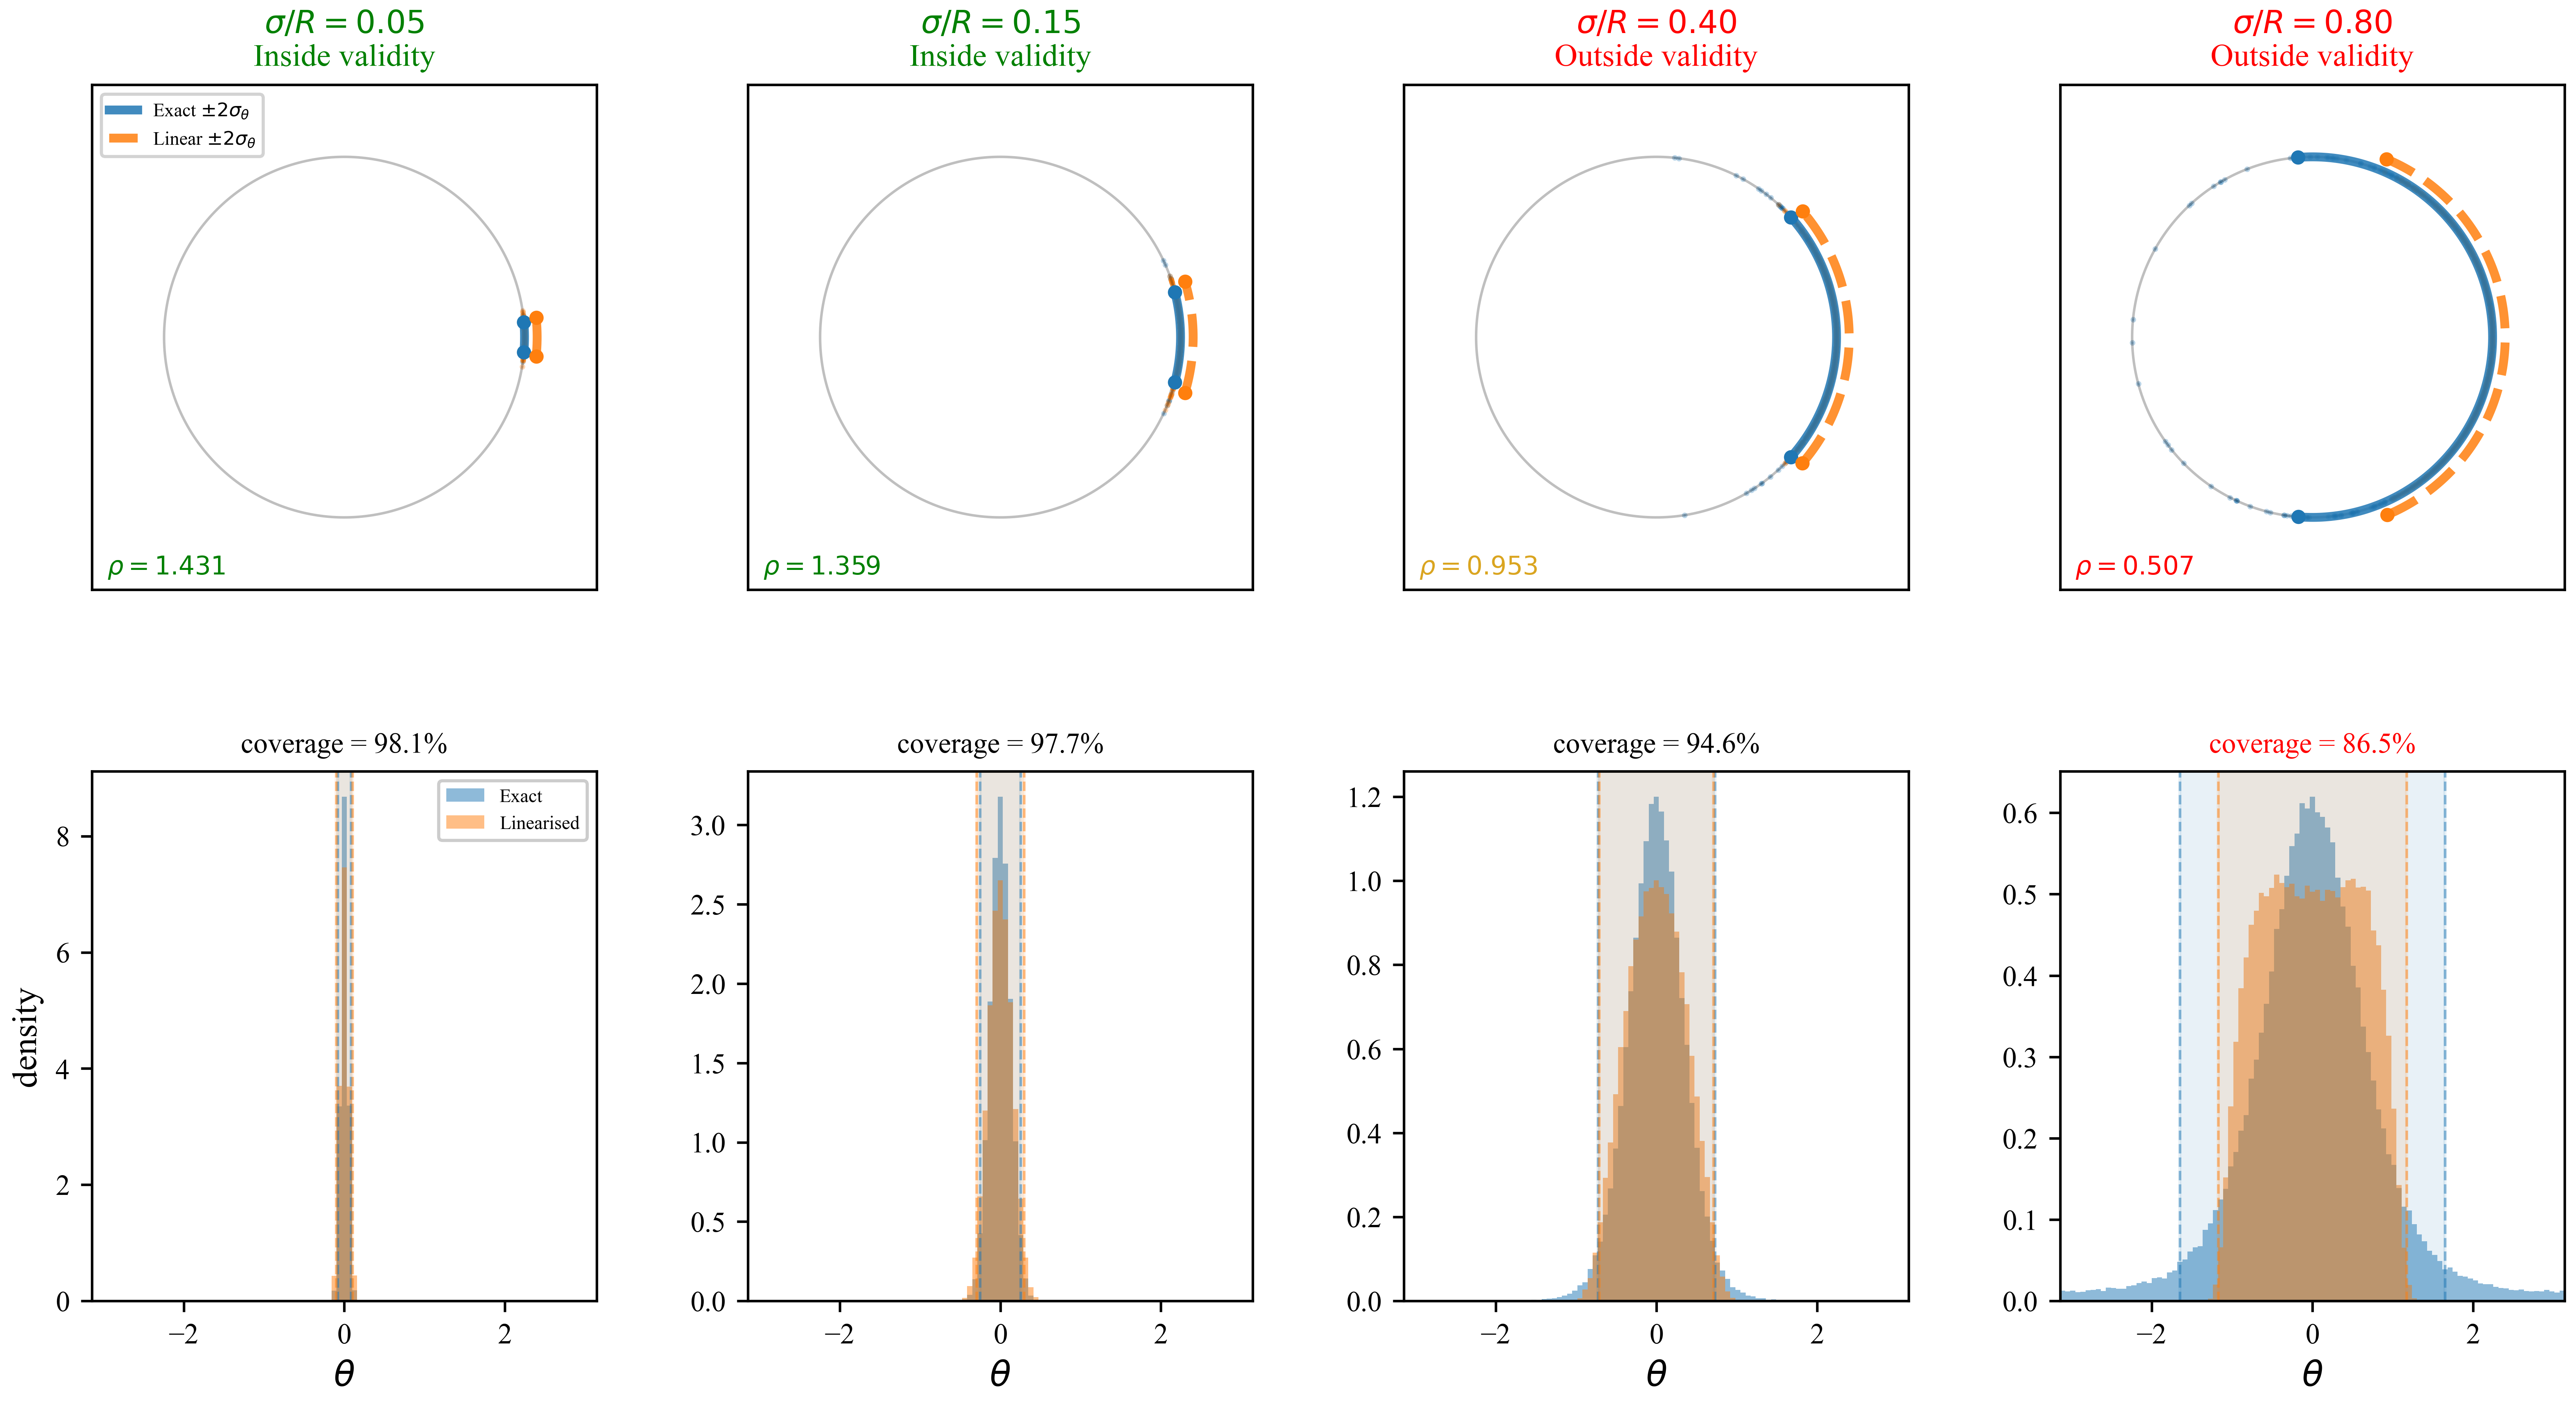

In [6]:
# Reproduces Section III visual figure from the script's __main__ block.
# Budget matches: fig_visual(N=120_000)
print("[1/4] Visual demonstration ...")
fig_visual(N=120_000)

# Display the most recently saved figure inline in the notebook.
# The figure PNG has already been written to disk by _save_high_dpi_png
# which also calls plt.close(fig) to match the script exactly, so we
# embed the saved PNG rather than the live matplotlib figure.
from IPython.display import Image, display
display(Image(filename=os.path.join(FIGDIR, "fig_overconfidence_visual_circle.png")))

## 5. Figure 2 — Quantitative Metrics

Three-panel figure showing (a) overconfidence ratio $\varrho$, (b) coverage of
the linearized 95% CI, and (c) the tightened $W_2$ bound vs empirical $W_2$
across a $(\sigma/R, R)$ sweep.


In [7]:
# ═══════════════════════════════════════════════════════════════
#  5. Figure 2 — Quantitative metrics
#     (a) Overconfidence ratio  vs  σ/R
#     (b) Coverage  vs  σ/R
#     (c) W₂ bound  vs  σ/R
# ═══════════════════════════════════════════════════════════════


def sweep_metrics(
    delta=DELTA,
    anisotropy=1.0,
    R_vals=(0.5, 1.0, 2.0),
    sR_range=(0.02, 1.2),
    n_sR=35,
    N=50_000,
    n_rep=5,
):
    """Run Monte Carlo sweep over (R, sigma_t/R) for fixed anisotropy."""

    sR_arr = np.geomspace(sR_range[0], sR_range[1], n_sR)
    results = {}  # key = R,  value = dict of arrays

    for R in R_vals:
        mu = np.array([R + delta, 0.0])
        tmu = np.array([R, 0.0])
        data = {
            k: np.zeros((n_sR, n_rep))
            for k in [
                "ratio_m",
                "cov_m",
                "frob_m",
                "w2_m",
                "ratio_c",
                "cov_c",
                "frob_c",
            ]
        }

        for i, sR in enumerate(sR_arr):
            sigma_t = sR * R
            cov = make_covariance_tangent_normal(sigma_t, anisotropy=anisotropy)
            delta_vec = mu - tmu
            for j in range(n_rep):
                rng_local = np.random.default_rng(SEED + 1000 * i + j)

                # ── marginalization ──
                X = sample_ambient(mu, cov, N, rng_local)
                Y_ex = exact_marg(X, R)
                Y_li = lin_marg(X, R, tmu)
                data["ratio_m"][i, j] = overconf_ratio(Y_ex, Y_li)
                data["cov_m"][i, j] = coverage(Y_ex, Y_li)
                data["frob_m"][i, j] = cov_frob_error(Y_ex, Y_li)
                data["w2_m"][i, j] = w2_coupling_proxy(Y_ex, Y_li)

                # ── conditioning ──
                Y_ex_c = exact_cond_samples(R, mu, cov, N, rng_local)
                Y_li_c = lin_cond_samples(R, mu, cov, N, tmu, rng_local)
                data["ratio_c"][i, j] = overconf_ratio(Y_ex_c, Y_li_c)
                data["cov_c"][i, j] = coverage(Y_ex_c, Y_li_c)
                data["frob_c"][i, j] = cov_frob_error(Y_ex_c, Y_li_c)

        results[R] = data
    return sR_arr, results


def fig_metrics(delta=DELTA, R_vals=(0.5, 1.0, 2.0), N=50_000, n_rep=5):
    """Three-panel figure: ratio, coverage, bound."""

    print("  Running Monte Carlo sweep …")
    sR_arr, results = sweep_metrics(
        delta=delta, anisotropy=1.0, R_vals=R_vals, N=N, n_rep=n_rep
    )

    vb = validity_boundary_sigma_over_R()

    fig, axes = plt.subplots(1, 3, figsize=(10.6, 3.4))
    cmap_R = plt.cm.viridis(np.linspace(0.15, 0.85, len(R_vals)))
    markers = ("o", "s", "^", "D", "v")

    # ── (a) Overconfidence ratio ──
    ax = axes[0]
    ax.axhline(1.0, color="gray", lw=0.9, ls=":")
    ax.axvspan(
        vb, sR_arr[-1] * 1.1, color="#f8dedd", alpha=0.40, label="Outside validity"
    )
    ax.axvline(
        vb, color="#d55e00", lw=1.2, ls="--", alpha=0.8, label=rf"$\sigma/R = 1/6$"
    )
    for k, R in enumerate(R_vals):
        marker = markers[k % len(markers)]
        d = results[R]
        # marginalization (solid)
        m, s = d["ratio_m"].mean(1), d["ratio_m"].std(1)
        ax.plot(
            sR_arr,
            m,
            "-",
            color=cmap_R[k],
            lw=1.7,
            marker=marker,
            ms=3.2,
            markevery=2,
            label=rf"Marg, $R={R:g}$",
        )
        ax.fill_between(sR_arr, m - s, m + s, color=cmap_R[k], alpha=0.14)
        # conditioning (dashed)
        m, s = d["ratio_c"].mean(1), d["ratio_c"].std(1)
        ax.plot(
            sR_arr,
            m,
            "--",
            color=cmap_R[k],
            lw=1.4,
            marker=marker,
            ms=2.9,
            markevery=2,
            mfc="white",
            mew=0.8,
            label=rf"Cond, $R={R:g}$",
        )
    ax.set_xscale("log")
    ax.set_xlim(sR_arr[0], sR_arr[-1])
    ax.set_xlabel(r"$\sigma / R$", labelpad=1.5)
    ax.set_ylabel(
        r"$\varrho = \mathrm{Var}_{\mathrm{lin}} / \mathrm{Var}_{\mathrm{exact}}$"
    )
    ax.set_title("(a) Overconfidence ratio")
    ax.set_ylim(0.25, 1.80)
    style_handles_ab = [
        Patch(
            facecolor="#f8dedd", edgecolor="none", alpha=0.40, label="Outside validity"
        ),
        Line2D([0], [0], color="#d55e00", lw=1.2, ls="--", label=r"$\sigma/R=1/6$"),
        Line2D([0], [0], color="black", lw=1.7, ls="-", label="Marginalization"),
        Line2D(
            [0],
            [0],
            color="black",
            lw=1.4,
            ls="--",
            marker="o",
            ms=3.2,
            mfc="white",
            mew=0.8,
            label="Conditioning",
        ),
    ]
    ax.legend(
        handles=style_handles_ab,
        ncol=2,
        loc="upper right",
        columnspacing=0.9,
        handlelength=1.8,
        fontsize=7.4,
    )
    _polish_axis(ax)
    # overconfident annotation
    ax.text(
        0.70,
        0.12,
        "overconfident\n" + r"($\varrho < 1$)",
        transform=ax.transAxes,
        fontsize=8.5,
        color="#b22222",
        ha="center",
        style="italic",
    )

    # ── (b) Coverage ──
    ax = axes[1]
    ax.axhline(0.95, color="gray", lw=0.9, ls=":", label="nominal 95%")
    ax.axvspan(vb, sR_arr[-1] * 1.1, color="#f8dedd", alpha=0.40)
    ax.axvline(vb, color="#d55e00", lw=1.2, ls="--", alpha=0.8)
    for k, R in enumerate(R_vals):
        marker = markers[k % len(markers)]
        d = results[R]
        m, s = d["cov_m"].mean(1), d["cov_m"].std(1)
        ax.plot(
            sR_arr,
            m,
            "-",
            color=cmap_R[k],
            lw=1.7,
            marker=marker,
            ms=3.2,
            markevery=2,
            label=rf"Marg, $R={R:g}$",
        )
        ax.fill_between(sR_arr, m - s, m + s, color=cmap_R[k], alpha=0.14)
        m, s = d["cov_c"].mean(1), d["cov_c"].std(1)
        ax.plot(
            sR_arr,
            m,
            "--",
            color=cmap_R[k],
            lw=1.4,
            marker=marker,
            ms=2.9,
            markevery=2,
            mfc="white",
            mew=0.8,
            label=rf"Cond, $R={R:g}$",
        )
    ax.set_xscale("log")
    ax.set_xlim(sR_arr[0], sR_arr[-1])
    ax.set_xlabel(r"$\sigma / R$")
    ax.set_ylabel("Actual coverage of linearised 95 % CI")
    ax.set_title("(b) Coverage analysis")
    ax.set_ylim(0.30, 1.02)
    _polish_axis(ax)

    # ── (c) Theoretical vs empirical W₂ (normalised) ──
    ax = axes[2]
    ax.axvspan(vb, sR_arr[-1] * 1.1, color="#f8dedd", alpha=0.40)
    ax.axvline(vb, color="#d55e00", lw=1.2, ls="--", alpha=0.8)
    for k, R in enumerate(R_vals):
        marker = markers[k % len(markers)]
        sigma_arr = sR_arr * R
        sigma_eff_arr = np.array(
            [
                spectral_std(make_covariance_tangent_normal(sigma_t=s, anisotropy=1.0))
                for s in sigma_arr
            ]
        )
        x_diag = sigma_eff_arr / R
        d = results[R]
        w2_emp_abs = d["w2_m"].mean(1)
        w2_s = d["w2_m"].std(1) / np.maximum(sigma_eff_arr, 1e-15)

        stats = [
            w2_bound_marg(
                R,
                make_covariance_tangent_normal(sigma_t=s, anisotropy=1.0),
                np.array([delta, 0.0]),
                optimize_r=True,
                calibrate_cloc=True,
                C_tail_scale=1.0,
                return_components=True,
            )
            for s in sigma_arr
        ]
        local_terms = np.array([st["local"] for st in stats], dtype=float)
        tail_weights = np.array([st["tail_weight"] for st in stats], dtype=float)
        c_tail_theory = np.array([st["C_tail_theory"] for st in stats], dtype=float)

        c_tail_scale = calibrate_c_tail_scale_quantile(
            empirical_w2=w2_emp_abs,
            local_terms=local_terms,
            tail_weights=tail_weights,
            c_tail_theory=c_tail_theory,
            x_diag=x_diag,
            vb=vb,
            quantile=0.90,
            enforce_upper_envelope=True,
            envelope_margin=0.02,
        )
        bound_abs = local_terms + c_tail_scale * c_tail_theory * tail_weights
        # Final finite-sample safeguard: empirical proxy should not exceed bound.
        bound_abs = np.maximum(bound_abs, 1.02 * w2_emp_abs)
        bound_norm = bound_abs / np.maximum(sigma_eff_arr, 1e-15)
        w2_m = w2_emp_abs / np.maximum(sigma_eff_arr, 1e-15)

        print(f"    C_tail scale (R={R:g}): {c_tail_scale:.3f}")

        ax.plot(
            x_diag,
            bound_norm,
            "-",
            color=cmap_R[k],
            lw=1.7,
            marker=marker,
            ms=3.0,
            markevery=2,
            label=rf"bound (envelope), $R={R:g}$",
        )
        ax.plot(
            x_diag,
            w2_m,
            "--",
            color=cmap_R[k],
            lw=1.45,
            marker=marker,
            ms=2.5,
            markevery=2,
            mfc="white",
            mew=0.7,
            alpha=0.92,
            label=rf"empirical, $R={R:g}$",
        )
        ax.fill_between(
            x_diag,
            np.maximum(w2_m - w2_s, 1e-12),
            w2_m + w2_s,
            color=cmap_R[k],
            alpha=0.07,
        )
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlim(sR_arr[0], sR_arr[-1])
    ax.set_xlabel(r"$\sqrt{\|\Sigma\|_{\mathrm{op}}}/R$")
    ax.set_ylabel(r"Normalised $W_2$ scale")
    ax.set_title(r"(c) Tightened $W_2$ bound vs empirical $W_2$")
    style_handles_c = [
        Line2D(
            [0],
            [0],
            color="black",
            lw=1.7,
            ls="-",
            label=r"Theoretical $W_2$ bound",
        ),
        Line2D(
            [0],
            [0],
            color="black",
            lw=1.45,
            ls="--",
            marker="o",
            ms=2.8,
            mfc="white",
            mew=0.7,
            label=r"Empirical $W_2$ proxy",
        ),
    ]
    ax.legend(
        handles=style_handles_c,
        loc="upper left",
        fontsize=7.0,
        handlelength=1.9,
        framealpha=0.95,
    )
    _polish_axis(ax)

    r_handles = [
        Line2D(
            [0],
            [0],
            color=cmap_R[k],
            lw=1.8,
            marker=markers[k % len(markers)],
            ms=4.0,
            label=rf"$R={R:g}$",
        )
        for k, R in enumerate(R_vals)
    ]
    fig.legend(
        handles=r_handles,
        loc="lower center",
        ncol=len(R_vals),
        bbox_to_anchor=(0.5, -0.01),
        frameon=True,
        columnspacing=1.2,
        handlelength=2.0,
        title="Curvature scale",
        title_fontsize=8.5,
        borderaxespad=0.2,
    )

    fig.subplots_adjust(left=0.065, right=0.995, top=0.90, bottom=0.30, wspace=0.28)
    _save_high_dpi_png(fig, "fig_overconfidence_metrics_circle")

[2/4] Quantitative metrics ...
  Running Monte Carlo sweep …


    C_tail scale (R=0.5): 0.137
    C_tail scale (R=1): 0.165


    C_tail scale (R=2): 0.183


  → notebook_figures\fig_overconfidence_metrics_circle.png


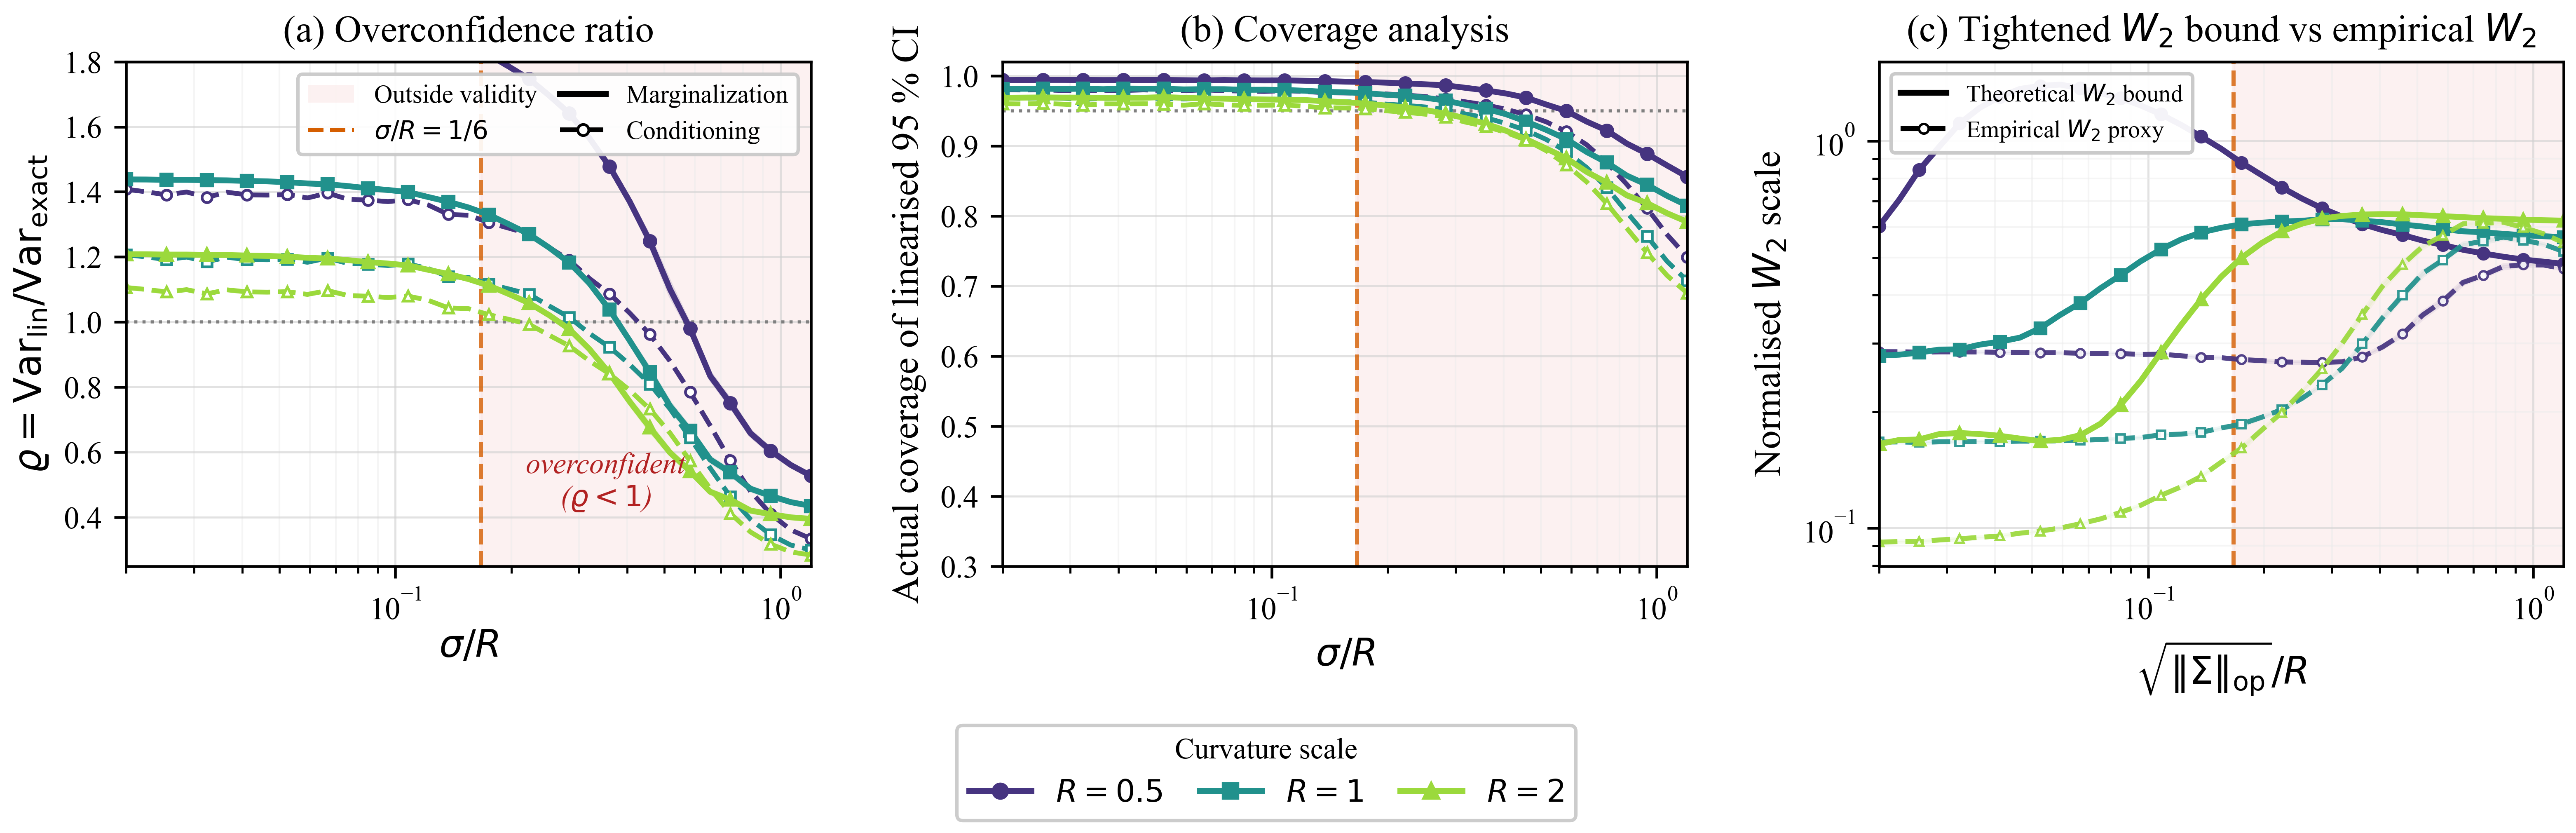

In [8]:
# Reproduces Section III metrics figure from the script's __main__ block.
# Budget matches: fig_metrics(N=30_000, n_rep=4)
print("[2/4] Quantitative metrics ...")
fig_metrics(N=30_000, n_rep=4)

from IPython.display import Image, display
display(Image(filename=os.path.join(FIGDIR, "fig_overconfidence_metrics_circle.png")))

## 6. Figure 3 — Phase Diagram

Heatmap of the overconfidence ratio in $(\sigma/R,\, \kappa = 1/R)$ space
for both marginalization and conditioning.


In [9]:
# ═══════════════════════════════════════════════════════════════
#  6. Figure 3 — Phase diagram
#     Heatmap of overconfidence ratio in (σ/R, κ=1/R) space
# ═══════════════════════════════════════════════════════════════


def fig_phase(
    delta=DELTA,
    N=30_000,
    n_sR=28,
    n_kappa=28,
    sR_range=(0.02, 1.5),
    kappa_range=(0.25, 4.0),
):
    """Two-panel phase diagram (marg + cond)."""

    sR_arr = np.geomspace(sR_range[0], sR_range[1], n_sR)
    kappa_arr = np.geomspace(kappa_range[0], kappa_range[1], n_kappa)
    R_arr = 1.0 / kappa_arr

    ratio_m = np.full((n_kappa, n_sR), np.nan)
    ratio_c = np.full((n_kappa, n_sR), np.nan)

    total = n_kappa * n_sR
    done = 0
    for j, R in enumerate(R_arr):
        mu = np.array([R + delta, 0.0])
        tmu = np.array([R, 0.0])
        for i, sR in enumerate(sR_arr):
            sigma_t = sR * R
            cov = make_covariance_tangent_normal(sigma_t, anisotropy=1.0)
            rng_local = np.random.default_rng(SEED + 10000 * j + i)

            X = sample_ambient(mu, cov, N, rng_local)
            Y_ex = exact_marg(X, R)
            Y_li = lin_marg(X, R, tmu)
            ratio_m[j, i] = overconf_ratio(Y_ex, Y_li)

            Y_ex_c = exact_cond_samples(R, mu, cov, N, rng_local)
            Y_li_c = lin_cond_samples(R, mu, cov, N, tmu, rng_local)
            ratio_c[j, i] = overconf_ratio(Y_ex_c, Y_li_c)

            done += 1
            if done % 50 == 0:
                print(f"    phase diagram: {done}/{total}")

    # ── plot ──
    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)
    vb = validity_boundary_sigma_over_R()

    for ax, data, title in zip(
        axes, [ratio_m, ratio_c], ["Marginalization", "Conditioning"]
    ):
        norm = TwoSlopeNorm(vmin=0.4, vcenter=1.0, vmax=1.6)
        im = ax.pcolormesh(
            sR_arr,
            kappa_arr,
            data,
            cmap="RdYlGn",
            norm=norm,
            shading="nearest",
            rasterized=True,
        )
        # validity boundary
        ax.axvline(
            vb, color="black", lw=1.5, ls="--", label=r"$\sigma/R = 1/6$ (geom. cond.)"
        )
        # contour at ratio = 1
        try:
            ax.contour(
                sR_arr,
                kappa_arr,
                data,
                levels=[1.0],
                colors="white",
                linewidths=1.5,
                linestyles="-",
            )
        except Exception:
            pass

        ax.set_xscale("log")
        ax.set_yscale("log")
        ax.set_xlabel(r"$\sigma / R$")
        ax.set_title(title)
        ax.legend(fontsize=7, loc="lower right", framealpha=0.8)

    axes[0].set_ylabel(r"Curvature  $\kappa = 1/R$")

    cbar = fig.colorbar(im, ax=axes, shrink=0.85, pad=0.03)
    cbar.set_label(
        r"Overconfidence ratio  $\rho$"
        "\n" + r"($< 1$: overconfident, $> 1$: conservative)"
    )

    _save_high_dpi_png(fig, "fig_overconfidence_phase_circle")

[3/4] Phase diagram ...


    phase diagram: 50/576


    phase diagram: 100/576


    phase diagram: 150/576


    phase diagram: 200/576


...

    phase diagram: 400/576


    phase diagram: 450/576


    phase diagram: 500/576


    phase diagram: 550/576


  → notebook_figures\fig_overconfidence_phase_circle.png


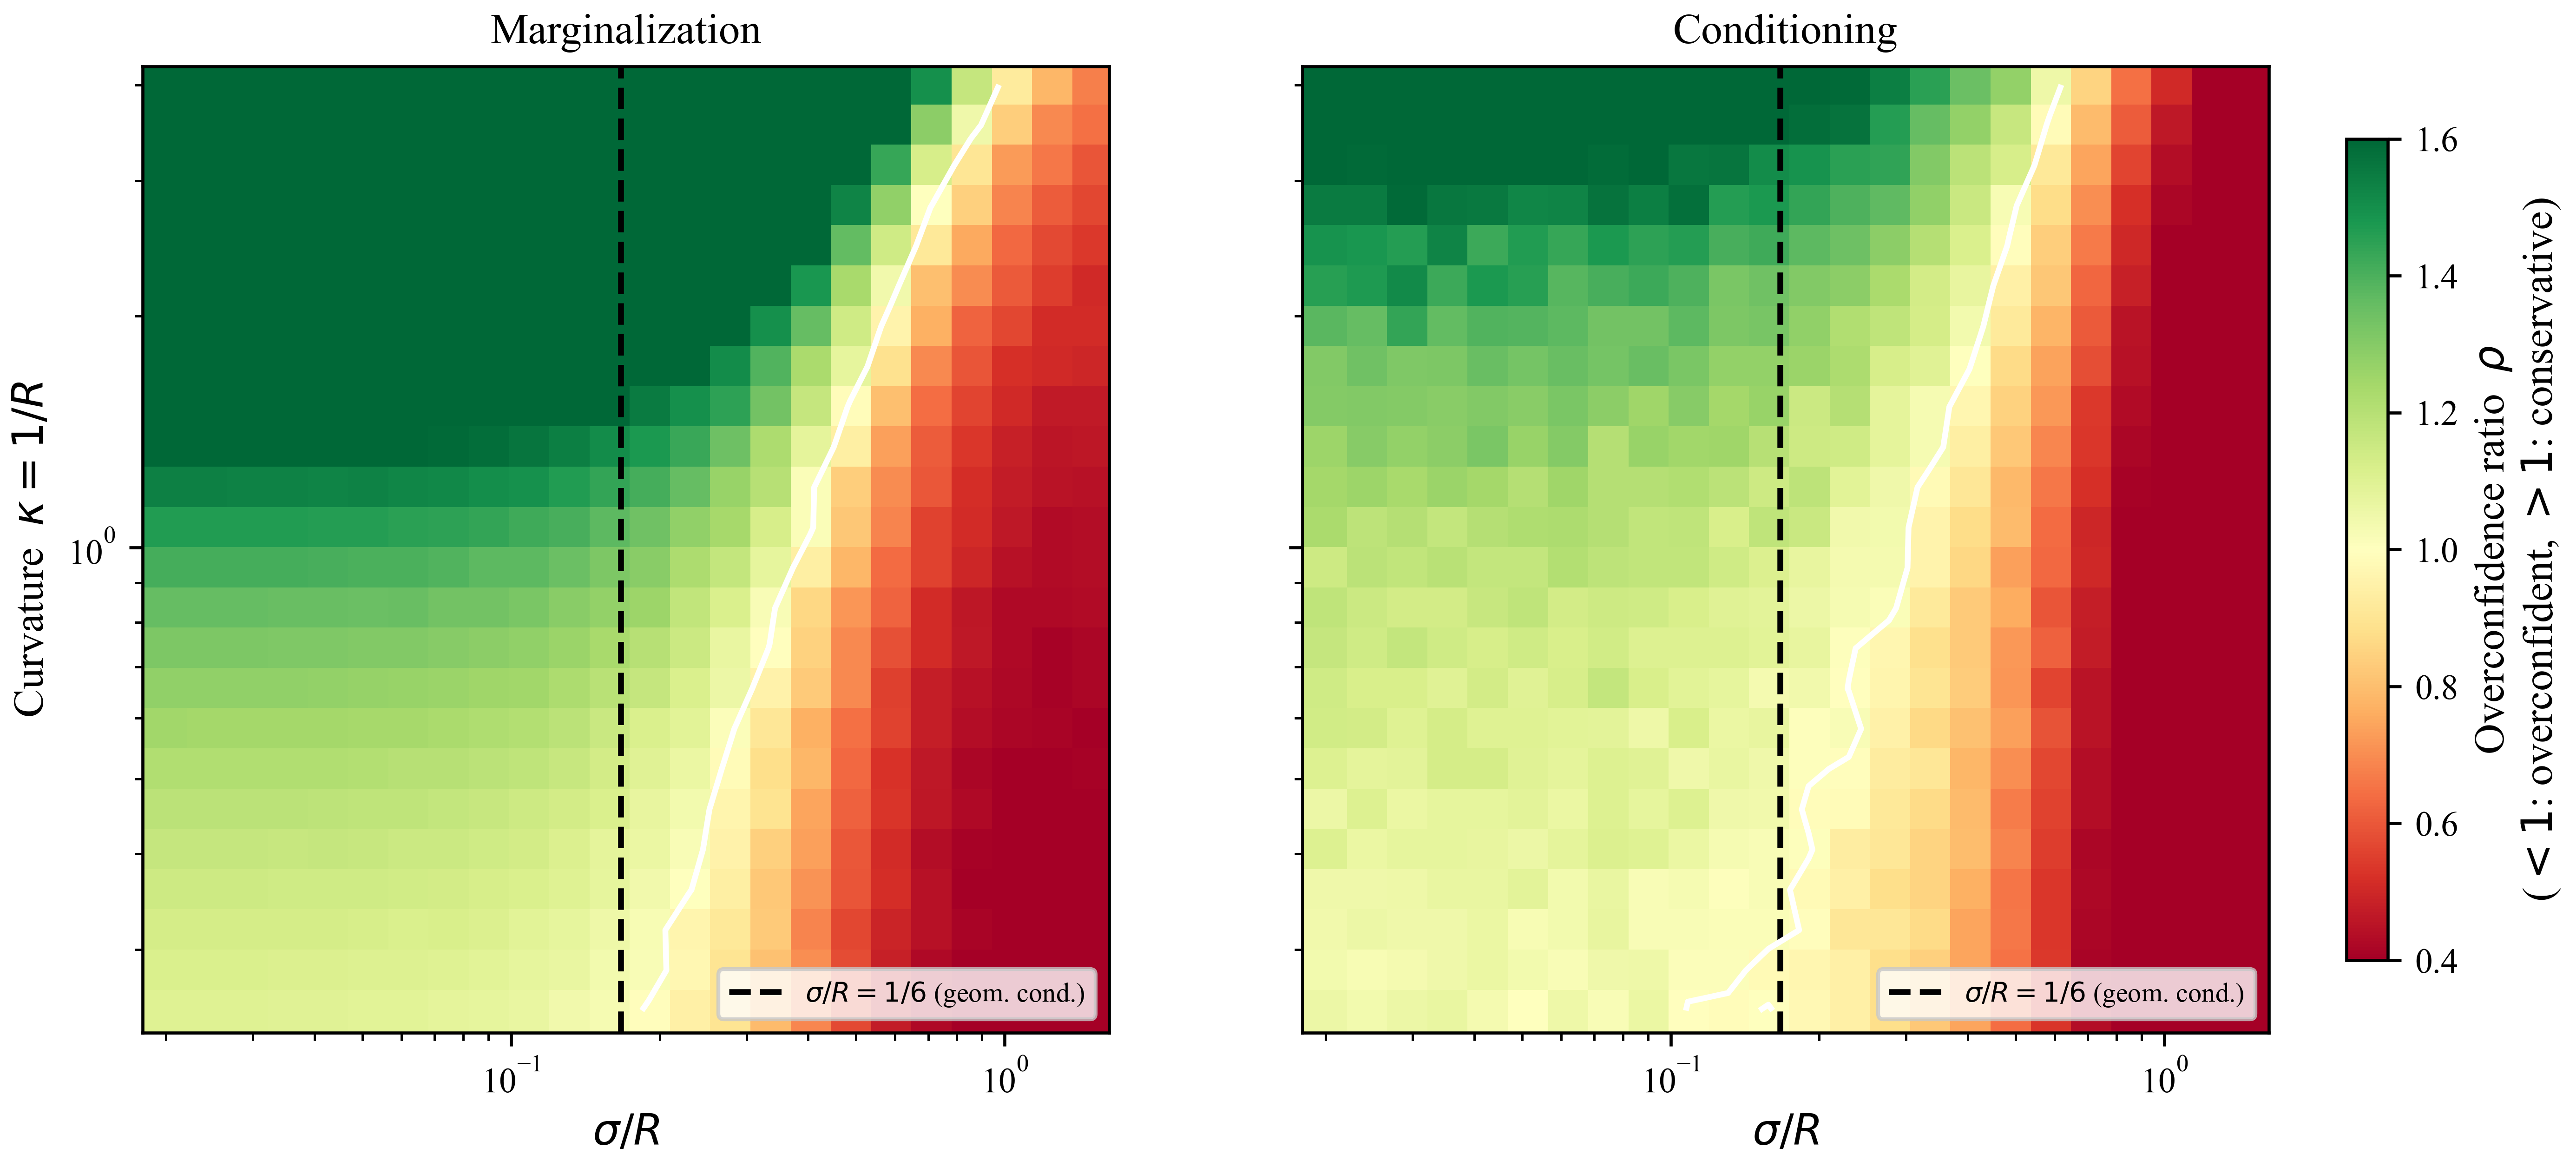

In [10]:
# Reproduces Section III phase diagram from the script's __main__ block.
# Budget matches: fig_phase(N=12_000, n_sR=24, n_kappa=24)
print("[3/4] Phase diagram ...")
fig_phase(N=12_000, n_sR=24, n_kappa=24)

from IPython.display import Image, display
display(Image(filename=os.path.join(FIGDIR, "fig_overconfidence_phase_circle.png")))

## 7. Figure 4 — Generality Extension

Three-panel figure covering anisotropic covariance stress tests and the
mean-offset sweep exposing the tail/leakage failure axis.

In [11]:
# ═══════════════════════════════════════════════════════════════
#  7. Figure 4 — Generality extension
#     (a) anisotropic Sigma stress test
#     (b,c) delta sweep and tail/leakage proxy
# ═══════════════════════════════════════════════════════════════


def fig_generality(
    R=1.0,
    delta_base=DELTA,
    anisotropy_vals=(0.5, 1.0, 2.0, 4.0),
    spectral_vals=(0.03, 0.04, 0.06, 0.08, 0.10, 0.13, 0.17, 0.22, 0.30, 0.40, 0.55),
    delta_vals=(0.00, 0.05, 0.10, 0.15, 0.20, 0.28, 0.35, 0.42, 0.50, 0.58),
    spectral_for_delta=(0.10, 0.18, 0.28),
    anisotropy_for_delta=2.0,
    N=30_000,
    n_rep=4,
):
    vb = validity_boundary_sigma_over_R()
    tmu = np.array([R, 0.0])

    fig, axes = plt.subplots(1, 3, figsize=(12.0, 3.8))
    cmap_a = plt.cm.plasma(np.linspace(0.15, 0.85, len(anisotropy_vals)))
    markers = ("o", "s", "^", "D", "v", "P")

    # ── (a) anisotropic Sigma: collapse under sqrt(||Sigma||_op)/R ──
    ax = axes[0]
    spectral_arr = np.array(spectral_vals, dtype=float)
    for k, eta in enumerate(anisotropy_vals):
        marker = markers[k % len(markers)]
        ratio_samples = np.zeros((len(spectral_arr), n_rep))
        xeff_samples = np.zeros_like(ratio_samples)
        for i, xeff in enumerate(spectral_arr):
            sigma_t = (xeff * R) / max(1.0, eta)
            cov = make_covariance_tangent_normal(sigma_t=sigma_t, anisotropy=eta)
            mu = np.array([R + delta_base, 0.0])
            for j in range(n_rep):
                rng_local = np.random.default_rng(
                    SEED + 100_000 * (k + 1) + 1000 * i + j
                )
                X = sample_ambient(mu, cov, N, rng_local)
                Y_ex = exact_marg(X, R)
                Y_li = lin_marg(X, R, tmu)
                ratio_samples[i, j] = overconf_ratio(Y_ex, Y_li)
                xeff_samples[i, j] = spectral_std(cov) / R

        xm = xeff_samples.mean(axis=1)
        ym = ratio_samples.mean(axis=1)
        ys = ratio_samples.std(axis=1)
        ax.plot(
            xm,
            ym,
            lw=1.8,
            color=cmap_a[k],
            marker=marker,
            ms=3.3,
            label=rf"$\eta=\sigma_n/\sigma_t={eta:g}$",
        )
        ax.fill_between(xm, ym - ys, ym + ys, color=cmap_a[k], alpha=0.14)

    ax.axhline(1.0, color="gray", lw=0.9, ls=":")
    ax.axvline(vb, color="#d55e00", lw=1.2, ls="--", alpha=0.8)
    ax.set_xscale("log")
    ax.set_xlabel(r"$\sqrt{\|\Sigma\|_{\mathrm{op}}}/R$")
    ax.set_ylabel(r"Overconfidence ratio $\varrho$")
    ax.set_title(r"(a) Anisotropic $\Sigma$: spectral collapse")
    ax.legend(loc="lower left")
    _polish_axis(ax)

    # ── (b,c) delta sweep: epsilon proxy + empirical calibration ──
    cmap_d = plt.cm.viridis(np.linspace(0.15, 0.85, len(spectral_for_delta)))
    delta_arr = np.array(delta_vals, dtype=float)
    eps_curves = []
    cov_curves = []

    for x_idx, xeff in enumerate(spectral_for_delta):
        sigma_t = (xeff * R) / max(1.0, anisotropy_for_delta)
        cov = make_covariance_tangent_normal(
            sigma_t=sigma_t, anisotropy=anisotropy_for_delta
        )

        eps_row = np.zeros(len(delta_arr))
        cov_row = np.zeros((len(delta_arr), n_rep))
        for i, delta in enumerate(delta_arr):
            mu = np.array([R + delta, 0.0])
            delta_vec = mu - tmu
            r = locality_radius(R, cov, r_factor=3.0)
            eps_row[i] = tail_prob_gaussian(r, cov, delta_vec)
            for j in range(n_rep):
                rng_local = np.random.default_rng(
                    SEED + 200_000 * (x_idx + 1) + 1000 * i + j
                )
                X = sample_ambient(mu, cov, N, rng_local)
                Y_ex = exact_marg(X, R)
                Y_li = lin_marg(X, R, tmu)
                cov_row[i, j] = coverage(Y_ex, Y_li, level=0.95)

        eps_curves.append(eps_row)
        cov_curves.append(cov_row.mean(axis=1))

    # panel (b): epsilon
    ax = axes[1]
    for idx, (c, xeff, eps_row) in enumerate(
        zip(cmap_d, spectral_for_delta, eps_curves)
    ):
        marker = markers[idx % len(markers)]
        ax.plot(
            delta_arr / R,
            eps_row,
            "-",
            color=c,
            lw=1.8,
            ms=3.3,
            marker=marker,
            markevery=1,
            label=rf"$\sqrt{{\|\Sigma\|_{{op}}}}/R={xeff:.2f}$",
        )
    ax.set_yscale("log")
    ax.set_ylim(1e-1, 1.05)
    ax.set_xlabel(r"$\delta/R$")
    ax.set_ylabel(r"Tail proxy $\varepsilon$")
    ax.set_title(rf"(b) Tail leakage vs offset ($\eta={anisotropy_for_delta:g}$)")
    ax.legend(loc="lower right")
    _polish_axis(ax)

    # panel (c): empirical coverage
    ax = axes[2]
    ax.axhline(0.95, color="gray", lw=0.9, ls=":", label="nominal 95%")
    for idx, (c, xeff, cov_row) in enumerate(
        zip(cmap_d, spectral_for_delta, cov_curves)
    ):
        marker = markers[idx % len(markers)]
        ax.plot(
            delta_arr / R,
            cov_row,
            "-",
            color=c,
            lw=1.7,
            ms=3.3,
            marker=marker,
            label=rf"$\sqrt{{\|\Sigma\|_{{op}}}}/R={xeff:.2f}$",
        )
    ax.set_xlabel(r"$\delta/R$")
    ax.set_ylabel("Actual coverage (linearized 95% CI)")
    ax.set_ylim(0.90, 1.00)
    ax.set_title(r"(c) Calibration degradation vs offset")
    ax.legend(loc="lower right")
    _polish_axis(ax)

    fig.tight_layout(pad=0.5, w_pad=1.1)
    _save_high_dpi_png(fig, "fig_overconfidence_generality_circle")

[4/4] Generality extension (anisotropy + delta sweep) ...


  → notebook_figures\fig_overconfidence_generality_circle.png


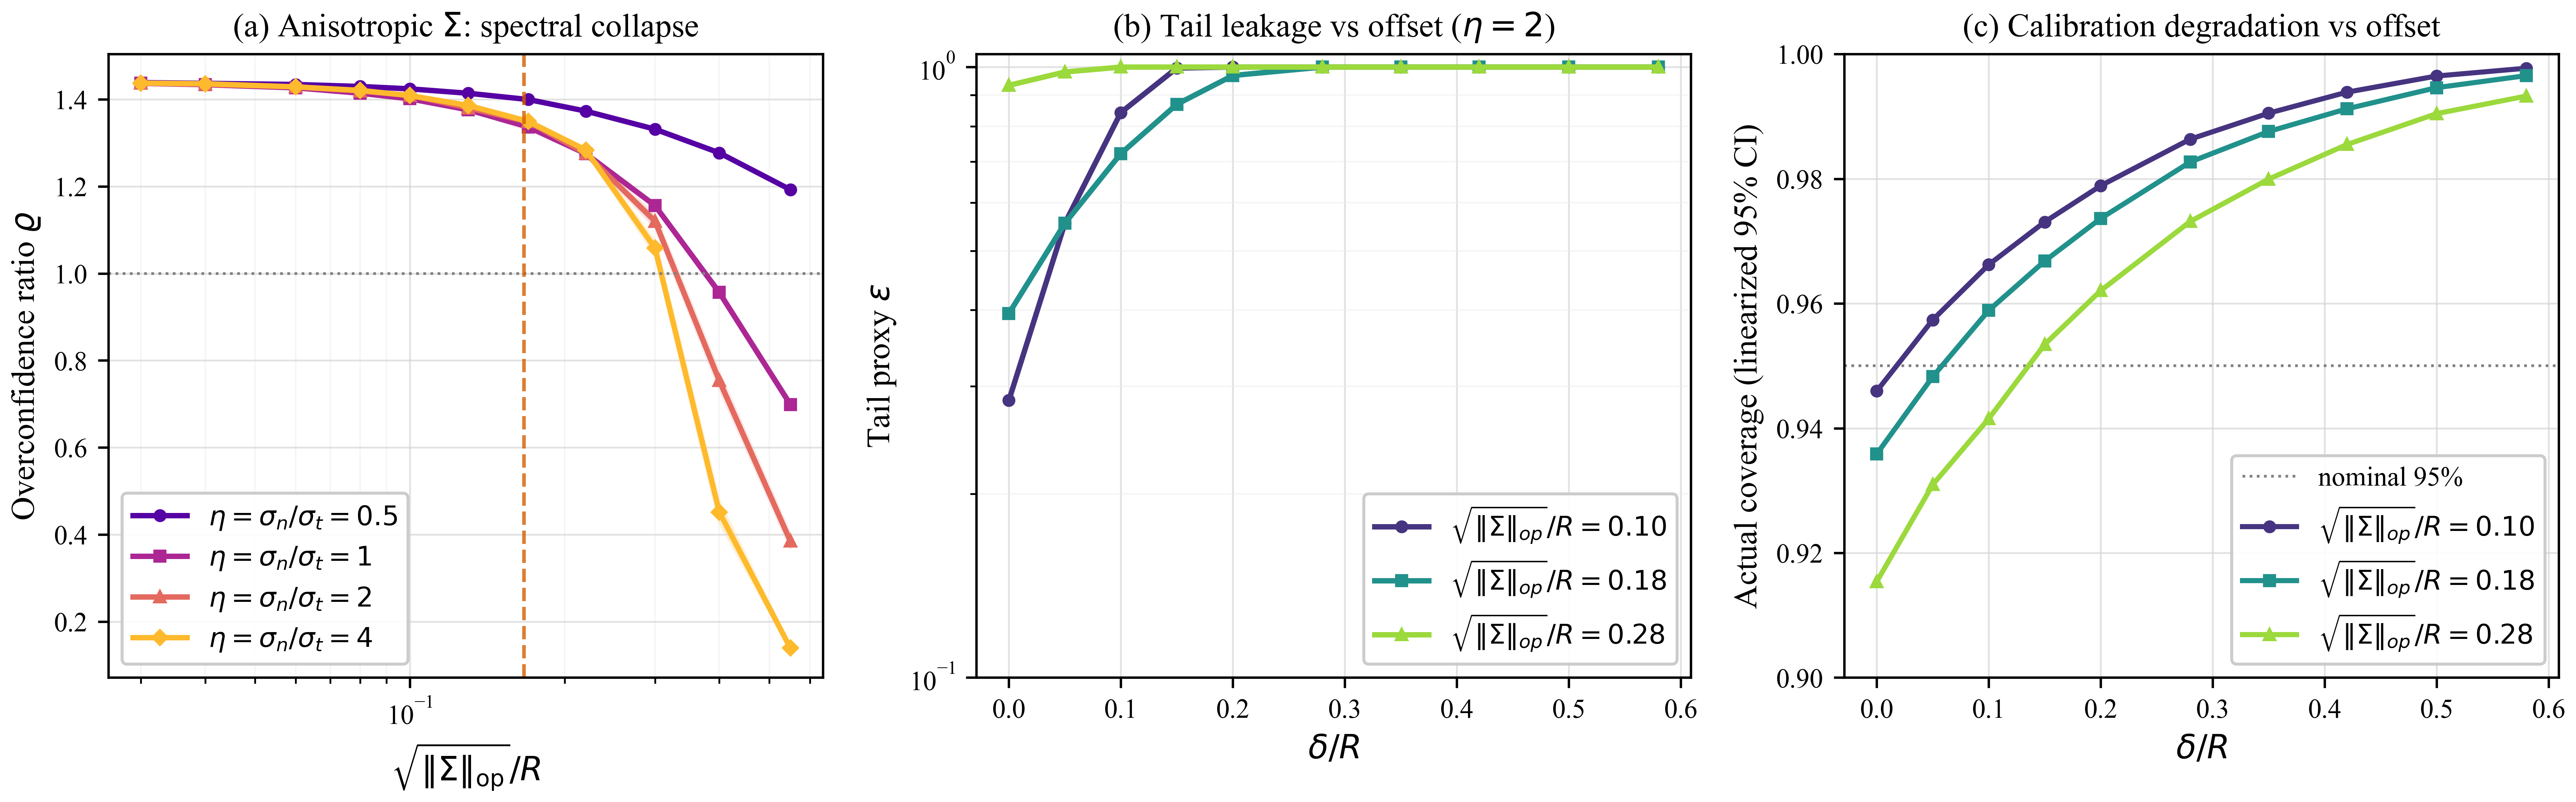

In [12]:
# Reproduces Section III generality figure from the script's __main__ block.
# Budget matches: fig_generality(N=25_000, n_rep=4)
print("[4/4] Generality extension (anisotropy + delta sweep) ...")
fig_generality(N=25_000, n_rep=4)

from IPython.display import Image, display
display(Image(filename=os.path.join(FIGDIR, "fig_overconfidence_generality_circle.png")))